# Mini-BLIP on Flickr30k: ITC + ITM + LM

This notebook trains a lightweight BLIP-style model with three objectives and plots the loss / validation curves.

In [1]:
!pip -q install transformers datasets==2.19.2 nltk pillow matplotlib pandas tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 22.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


## Imports and setup

In [1]:
import os
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, ViTImageProcessor, ViTModel
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


device: cpu


## Configuration

In [3]:
@dataclass
class Config:
    hf_dataset_name: str = "nlphuji/flickr30k"
    vit_model_name: str = "google/vit-base-patch16-224-in21k"
    tokenizer_name: str = "gpt2"

    max_len: int = 32
    batch_size: int = 16
    num_workers: int = 4
    num_epochs: int = 10
    lr: float = 3e-5
    weight_decay: float = 1e-4  # L2 Regularization

    d_model: int = 512
    n_heads: int = 4
    num_layers: int = 4
    d_ff: int = 1024
    dropout: float = 0.1

    freeze_vit: bool = True

    lambda_lm: float = 1.0
    lambda_itc: float = 0.5
    lambda_itm: float = 0.5
    temperature_init: float = 0.07

    subset_train_images: int = 12000
    subset_val_images: int = 1000
    max_bleu_eval_images: int = 300
    qualitative_examples: int = 3

cfg = Config()

## Load and normalize Flickr30k

In [4]:
from datasets import load_dataset

raw = load_dataset(cfg.hf_dataset_name)
print(raw)
print("available outer keys:", list(raw.keys()))

Generating test split:   0%|          | 0/31014 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})
available outer keys: ['test']


In [5]:
import pandas as pd
import random
from tqdm import tqdm
from typing import Dict, List, Optional

def _extract_captions(example: Dict) -> List[str]:
    for key in ["caption", "captions", "sentences", "sentence", "annotations"]:
        if key not in example:
            continue
        value = example[key]

        if isinstance(value, str):
            return [value]

        if isinstance(value, list):
            if len(value) == 0:
                return []
            if isinstance(value[0], str):
                return value

            caps = []
            for item in value:
                if isinstance(item, dict):
                    for k in ["raw", "caption", "sentence", "sent"]:
                        if k in item and isinstance(item[k], str):
                            caps.append(item[k])
                            break
            if caps:
                return caps

        if isinstance(value, dict):
            for k in ["raw", "caption", "sentence", "sent"]:
                if k in value and isinstance(value[k], list):
                    return [x for x in value[k] if isinstance(x, str)]

    raise ValueError(f"Could not find captions in example keys: {list(example.keys())}")


def split_to_rows(ds, split_name: str) -> pd.DataFrame:
    rows = []
    for idx in tqdm(range(len(ds)), desc=f"normalizing {split_name}"):
        ex = ds[idx]
        image = ex["image"]

        image_id = ex.get(
            "image_id",
            ex.get("img_id", ex.get("filename", ex.get("file_name", idx)))
        )

        captions = _extract_captions(ex)

        row_split = ex.get("split", split_name)

        for cap in captions:
            rows.append({
                "image_id": str(image_id),
                "caption": str(cap).strip(),
                "image": image,
                "split": str(row_split).lower()
            })

    return pd.DataFrame(rows)


def maybe_subsample_by_image(df: pd.DataFrame, max_images: Optional[int], seed: int) -> pd.DataFrame:
    if max_images is None:
        return df.reset_index(drop=True)

    image_ids = sorted(df["image_id"].unique().tolist())
    if max_images >= len(image_ids):
        return df.reset_index(drop=True)

    rng = random.Random(seed)
    rng.shuffle(image_ids)
    keep = set(image_ids[:max_images])
    return df[df["image_id"].isin(keep)].reset_index(drop=True)


if "train" in raw:
    train_df = split_to_rows(raw["train"], "train")

    if "validation" in raw:
        val_df = split_to_rows(raw["validation"], "validation")
    elif "val" in raw:
        val_df = split_to_rows(raw["val"], "val")
    else:
        val_df = split_to_rows(raw["test"], "test")

else:
    only_key = list(raw.keys())[0]
    full_df = split_to_rows(raw[only_key], only_key)

    print("available inner splits:", full_df["split"].value_counts(dropna=False).to_dict())

    train_df = full_df[full_df["split"].isin(["train"])].reset_index(drop=True)
    val_df = full_df[full_df["split"].isin(["val", "validation"])].reset_index(drop=True)
    test_df = full_df[full_df["split"].isin(["test"])].reset_index(drop=True)

train_df = maybe_subsample_by_image(train_df, cfg.subset_train_images, SEED)
val_df = maybe_subsample_by_image(val_df, cfg.subset_val_images, SEED)

print("train rows:", len(train_df), "train images:", train_df["image_id"].nunique())
print("val rows:", len(val_df), "val images:", val_df["image_id"].nunique())


normalizing test: 100%|██████████| 31014/31014 [01:39<00:00, 313.16it/s]


available inner splits: {'train': 145000, 'val': 5070, 'test': 5000}
train rows: 60000 train images: 12000
val rows: 5000 val images: 1000


## Tokenizer and image processor

In [6]:
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)
tokenizer.add_special_tokens({"bos_token": "<bos>", "eos_token": "<eos>"})
tokenizer.pad_token = tokenizer.eos_token

processor = ViTImageProcessor.from_pretrained(cfg.vit_model_name)

print("vocab size:", len(tokenizer))
print("bos:", tokenizer.bos_token_id, "eos:", tokenizer.eos_token_id, "pad:", tokenizer.pad_token_id)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

vocab size: 50259
bos: 50257 eos: 50258 pad: 50258


## Dataset and dataloaders
(image_id, image, caption) -> pixel_values, input_ids, labels

In [7]:
class Flickr30kRowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, processor, max_len: int = 32):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.processor = processor
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = row["image"]
        if not isinstance(image, Image.Image):
            image = Image.open(image).convert("RGB")
        else:
            image = image.convert("RGB")

        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        caption = row["caption"]
        tokens = self.tokenizer.encode(caption, add_special_tokens=False)
        tokens = tokens[: self.max_len - 2]

        input_ids = [self.tokenizer.bos_token_id] + tokens
        labels = tokens + [self.tokenizer.eos_token_id]

        pad_len = self.max_len - len(input_ids)
        input_ids += [self.tokenizer.pad_token_id] * pad_len
        labels += [self.tokenizer.pad_token_id] * pad_len

        return {
            "pixel_values": pixel_values,
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "caption": caption,
            "image_id": row["image_id"],
        }


def collate_fn(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch], dim=0),
        "input_ids": torch.stack([x["input_ids"] for x in batch], dim=0),
        "labels": torch.stack([x["labels"] for x in batch], dim=0),
        "caption": [x["caption"] for x in batch],
        "image_id": [x["image_id"] for x in batch],
    }


train_dataset = Flickr30kRowDataset(train_df, tokenizer, processor, max_len=cfg.max_len)
val_dataset = Flickr30kRowDataset(val_df, tokenizer, processor, max_len=cfg.max_len)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 3750
val batches: 313


## Model

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q = self.q_linear(q).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.k_linear(k).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.v_linear(v).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        x, attn = self.attention(q, k, v, mask)
        x = x.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        x = self.out(x)
        return self.dropout(x), attn


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_feats, tgt_mask=None, memory_mask=None):
        _x, self_attn = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(_x))
        _x, cross_attn = self.cross_attn(x, encoder_feats, encoder_feats, memory_mask)
        x = self.norm2(x + self.dropout(_x))
        _x = self.ff(x)
        x = self.norm3(x + self.dropout(_x))
        return x, self_attn, cross_attn


class TextDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, num_layers=4, d_ff=2048, dropout=0.1, max_len=64, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(num_layers)])
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight
        self.dropout = nn.Dropout(dropout)

#                       1 0 0                  1 0 0
#   1 1 0 pad_mask  &   1 1 0   causal_mask -> 1 1 0  The last column is masked
#                       1 1 1                  1 1 0
    def generate_causal_mask(self, tgt_ids):
        _, T = tgt_ids.shape
        device = tgt_ids.device
        pad_mask = (tgt_ids != self.pad_idx).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(torch.ones(T, T, device=device)).bool().unsqueeze(0).unsqueeze(0)
        return pad_mask & causal_mask

    def forward(self, tgt_ids, encoder_feats):
        tgt_mask = self.generate_causal_mask(tgt_ids)
        x = self.embedding(tgt_ids) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, encoder_feats, tgt_mask=tgt_mask, memory_mask=None)
            self_attns.append(self_attn)
            cross_attns.append(cross_attn)
        logits = self.lm_head(x)
        return logits, self_attns, cross_attns, x

# pixel_values -> encode_image -> image_feats, image_cls
#                                |            |
#                                |            +--> ITC / ITM
#                                |
# input_ids ------------------> decoder ------+--> LM
#    |
#    +--> encode_text_for_heads -------------> text_cls -> ITC / ITM
class MiniBLIP_ITC_ITM_LM(nn.Module):
    def __init__(self, vocab_size, vit_model_name="google/vit-base-patch16-224-in21k", d_model=512,
                 n_heads=4, num_layers=4, d_ff=1024, dropout=0.1, max_len=64,
                 pad_idx=0, freeze_vit=True, temperature_init=0.07):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model_name)
        vit_hidden = self.vit.config.hidden_size
        if freeze_vit:
            for p in self.vit.parameters():
                p.requires_grad = False
        self.image_proj = nn.Linear(vit_hidden, d_model)
        self.decoder = TextDecoder(vocab_size, d_model, n_heads, num_layers, d_ff, dropout, max_len, pad_idx)
        self.itc_image_proj = nn.Linear(d_model, d_model)
        self.itc_text_proj = nn.Linear(d_model, d_model)
        self.itm_head = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1.0 / temperature_init)))

    def encode_image(self, pixel_values):
        # patch size：16
        vit_outputs = self.vit(pixel_values=pixel_values) # [B, 3, 224, 224] -> [B, 197, 768]
        image_feats = self.image_proj(vit_outputs.last_hidden_state) # [B, 197, 768]->[B, 197, 512]
        image_cls = image_feats[:, 0] # [B, 512] for ITC and ITM
        return image_feats, image_cls

    def encode_text_for_heads(self, input_ids):
        x = self.decoder.embedding(input_ids) * math.sqrt(self.decoder.d_model)
        x = self.decoder.pos_encoding(x)
        x = self.decoder.dropout(x)
        mask = (input_ids != self.decoder.pad_idx).float().unsqueeze(-1)
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return x, pooled

    def forward(self, pixel_values, input_ids, itm_negative_input_ids=None):
        image_feats, image_cls = self.encode_image(pixel_values)
        lm_logits, self_attns, cross_attns, decoder_hidden = self.decoder(input_ids, image_feats)
        _, text_cls = self.encode_text_for_heads(input_ids)
        image_emb = F.normalize(self.itc_image_proj(image_cls), dim=-1)
        text_emb = F.normalize(self.itc_text_proj(text_cls), dim=-1)

        pos_pair = torch.cat([image_cls, text_cls], dim=-1)
        itm_pos_logits = self.itm_head(pos_pair).squeeze(-1)
        itm_neg_logits = None
        if itm_negative_input_ids is not None:
            _, neg_text_cls = self.encode_text_for_heads(itm_negative_input_ids)
            neg_pair = torch.cat([image_cls, neg_text_cls], dim=-1)
            itm_neg_logits = self.itm_head(neg_pair).squeeze(-1)

        return {
            "lm_logits": lm_logits,
            "self_attns": self_attns,
            "cross_attns": cross_attns,
            "image_feats": image_feats,
            "decoder_hidden": decoder_hidden,
            "image_cls": image_cls,
            "text_cls": text_cls,
            "image_emb": image_emb,
            "text_emb": text_emb,
            "itm_pos_logits": itm_pos_logits,
            "itm_neg_logits": itm_neg_logits,
            "logit_scale": self.logit_scale.exp().clamp(max=100),
        }


## Build model and helpers

In [9]:

model = MiniBLIP_ITC_ITM_LM(
    vocab_size=len(tokenizer),
    vit_model_name=cfg.vit_model_name,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    num_layers=cfg.num_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    max_len=cfg.max_len,
    pad_idx=tokenizer.pad_token_id,
    freeze_vit=cfg.freeze_vit,
    temperature_init=cfg.temperature_init,
).to(DEVICE)

model.decoder.embedding = nn.Embedding(len(tokenizer), model.decoder.d_model, padding_idx=tokenizer.pad_token_id).to(DEVICE)
model.decoder.lm_head = nn.Linear(model.decoder.d_model, len(tokenizer), bias=False).to(DEVICE)
model.decoder.lm_head.weight = model.decoder.embedding.weight

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
lm_loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
itm_loss_fn = nn.BCEWithLogitsLoss()

print("parameters (M):", round(sum(p.numel() for p in model.parameters()) / 1e6, 2))


def make_negative_input_ids(input_ids: torch.Tensor) -> torch.Tensor:
    if input_ids.size(0) == 1:
        return input_ids.clone()
    shift = torch.randint(1, input_ids.size(0), (1,), device=input_ids.device).item()
    return torch.roll(input_ids, shifts=shift, dims=0)


def compute_itc_loss(image_emb: torch.Tensor, text_emb: torch.Tensor, logit_scale: torch.Tensor):
    logits_per_image = logit_scale * image_emb @ text_emb.t()
    logits_per_text = logits_per_image.t()
    targets = torch.arange(image_emb.size(0), device=image_emb.device)
    loss_i = F.cross_entropy(logits_per_image, targets)
    loss_t = F.cross_entropy(logits_per_text, targets)
    return 0.5 * (loss_i + loss_t), logits_per_image


def compute_itm_loss(itm_pos_logits: torch.Tensor, itm_neg_logits: torch.Tensor):
    pos_labels = torch.ones_like(itm_pos_logits)
    neg_labels = torch.zeros_like(itm_neg_logits)
    loss = 0.5 * (itm_loss_fn(itm_pos_logits, pos_labels) + itm_loss_fn(itm_neg_logits, neg_labels))
    preds = torch.cat([torch.sigmoid(itm_pos_logits), torch.sigmoid(itm_neg_logits)], dim=0)
    labels = torch.cat([pos_labels, neg_labels], dim=0)
    acc = ((preds >= 0.5).float() == labels).float().mean().item()
    return loss, acc


def retrieval_r1(logits_per_image: torch.Tensor) -> float:
    targets = torch.arange(logits_per_image.size(0), device=logits_per_image.device)
    preds = logits_per_image.argmax(dim=1)
    return (preds == targets).float().mean().item()


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

parameters (M): 126.18


## Generation and evaluation helpers

In [10]:

@torch.no_grad()
def generate_caption(model, processor, tokenizer, image, device, max_len=30):
    model.eval()
    if not isinstance(image, Image.Image):
        image = Image.open(image).convert("RGB")
    else:
        image = image.convert("RGB")

    pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(device)
    image_feats, _ = model.encode_image(pixel_values)
    generated = torch.tensor([[tokenizer.bos_token_id]], dtype=torch.long, device=device)

    for _ in range(max_len):
        logits, _, _, _ = model.decoder(generated, image_feats)
        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    ids = generated[0].tolist()
    if ids and ids[0] == tokenizer.bos_token_id:
        ids = ids[1:]
    if tokenizer.eos_token_id in ids:
        ids = ids[:ids.index(tokenizer.eos_token_id)]
    return tokenizer.decode(ids, skip_special_tokens=True).strip()


def build_reference_dict(df: pd.DataFrame):
    ref = {}
    for _, row in df.iterrows():
        ref.setdefault(row["image_id"], []).append(row["caption"])
    return ref


@torch.no_grad()
def evaluate_lm_bleu(model, val_df, tokenizer, processor, device, max_images=None):
    ref_dict = build_reference_dict(val_df)
    image_ids = sorted(ref_dict.keys())
    if max_images is not None:
        image_ids = image_ids[:max_images]
    image_lookup = val_df.drop_duplicates("image_id").set_index("image_id")["image"].to_dict()

    references, hypotheses = [], []
    for image_id in tqdm(image_ids, desc="BLEU eval"):
        image = image_lookup[image_id]
        pred = generate_caption(model, processor, tokenizer, image, device, max_len=cfg.max_len)
        references.append([cap.lower().split() for cap in ref_dict[image_id]])
        hypotheses.append(pred.lower().split())

    smoothie = SmoothingFunction().method1
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie),
    }


@torch.no_grad()
def evaluate_itc_itm(model, dataloader, device, max_batches=None):
    model.eval()
    itc_losses, itm_losses, itm_accs, r1s = [], [], [], []

    for batch_idx, batch in enumerate(tqdm(dataloader, desc="ITC/ITM eval")):
        if max_batches is not None and batch_idx >= max_batches:
            break
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        neg_input_ids = make_negative_input_ids(input_ids)
        outputs = model(pixel_values, input_ids, itm_negative_input_ids=neg_input_ids)

        itc_loss, logits_per_image = compute_itc_loss(outputs["image_emb"], outputs["text_emb"], outputs["logit_scale"])
        itm_loss, itm_acc = compute_itm_loss(outputs["itm_pos_logits"], outputs["itm_neg_logits"])
        itc_losses.append(itc_loss.item())
        itm_losses.append(itm_loss.item())
        itm_accs.append(itm_acc)
        r1s.append(retrieval_r1(logits_per_image))

    return {
        "val_itc_loss": float(np.mean(itc_losses)),
        "val_itm_loss": float(np.mean(itm_losses)),
        "val_itm_acc": float(np.mean(itm_accs)),
        "val_itc_r1": float(np.mean(r1s)),
    }


## Training

In [11]:

history = []
best_bleu4 = -1.0
best_path = "/content/best_miniblip_flickr30k_itc_itm_lm.pt"

for epoch in range(cfg.num_epochs):
    model.train()
    train_total_losses, train_lm_losses, train_itc_losses, train_itm_losses = [], [], [], []
    train_itm_accs, train_itc_r1s = [], []

    progress = tqdm(train_loader, desc=f"epoch {epoch+1}/{cfg.num_epochs}")
    for batch in progress:
        pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)
        neg_input_ids = make_negative_input_ids(input_ids)

        optimizer.zero_grad()
        outputs = model(pixel_values, input_ids, itm_negative_input_ids=neg_input_ids)

        lm_logits = outputs["lm_logits"]
        B, T, V = lm_logits.shape
        lm_loss = lm_loss_fn(lm_logits.reshape(B * T, V), labels.reshape(-1))
        itc_loss, logits_per_image = compute_itc_loss(outputs["image_emb"], outputs["text_emb"], outputs["logit_scale"])
        itm_loss, itm_acc = compute_itm_loss(outputs["itm_pos_logits"], outputs["itm_neg_logits"])

        total_loss = cfg.lambda_lm * lm_loss + cfg.lambda_itc * itc_loss + cfg.lambda_itm * itm_loss
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_total_losses.append(total_loss.item())
        train_lm_losses.append(lm_loss.item())
        train_itc_losses.append(itc_loss.item())
        train_itm_losses.append(itm_loss.item())
        train_itm_accs.append(itm_acc)
        train_itc_r1s.append(retrieval_r1(logits_per_image))

        progress.set_postfix({
            "total": f"{np.mean(train_total_losses):.3f}",
            "lm": f"{np.mean(train_lm_losses):.3f}",
            "itc": f"{np.mean(train_itc_losses):.3f}",
            "itm": f"{np.mean(train_itm_losses):.3f}",
        })

    val_pair_metrics = evaluate_itc_itm(model, val_loader, DEVICE)
    bleu_scores = evaluate_lm_bleu(model, val_df, tokenizer, processor, DEVICE, max_images=cfg.max_bleu_eval_images)

    epoch_record = {
        "epoch": epoch + 1,
        "train_total_loss": float(np.mean(train_total_losses)),
        "train_lm_loss": float(np.mean(train_lm_losses)),
        "train_itc_loss": float(np.mean(train_itc_losses)),
        "train_itm_loss": float(np.mean(train_itm_losses)),
        "train_itm_acc": float(np.mean(train_itm_accs)),
        "train_itc_r1": float(np.mean(train_itc_r1s)),
        **val_pair_metrics,
        **bleu_scores,
    }
    history.append(epoch_record)

    print("\nEpoch summary")
    for k, v in epoch_record.items():
        if k == "epoch":
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")

    if epoch_record["BLEU-4"] > best_bleu4:
        best_bleu4 = epoch_record["BLEU-4"]
        torch.save(model.state_dict(), best_path)
        print(f"saved best checkpoint to {best_path}")

history_df = pd.DataFrame(history)
history_df


BLEU eval: 100%|██████████| 300/300 [01:02<00:00,  4.82it/s]



Epoch summary
epoch: 1
train_total_loss: 23.3774
train_lm_loss: 22.1115
train_itc_loss: 1.8135
train_itm_loss: 0.7183
train_itm_acc: 0.5038
train_itc_r1: 0.4334
val_itc_loss: 2.1494
val_itm_loss: 0.6954
val_itm_acc: 0.5104
val_itc_r1: 0.2127
BLEU-1: 0.3042
BLEU-2: 0.1948
BLEU-3: 0.1225
BLEU-4: 0.0772
saved best checkpoint to /content/best_miniblip_flickr30k_itc_itm_lm.pt


BLEU eval: 100%|██████████| 300/300 [01:02<00:00,  4.83it/s]



Epoch summary
epoch: 2
train_total_loss: 11.0898
train_lm_loss: 10.1807
train_itc_loss: 1.1224
train_itm_loss: 0.6957
train_itm_acc: 0.5216
train_itc_r1: 0.6515
val_itc_loss: 2.1207
val_itm_loss: 0.6891
val_itm_acc: 0.5356
val_itc_r1: 0.2234
BLEU-1: 0.2747
BLEU-2: 0.1762
BLEU-3: 0.1108
BLEU-4: 0.0714


BLEU eval: 100%|██████████| 300/300 [01:02<00:00,  4.82it/s]


...

BLEU eval: 100%|██████████| 300/300 [01:02<00:00,  4.79it/s]



Epoch summary
epoch: 9
train_total_loss: 4.8910
train_lm_loss: 4.4325
train_itc_loss: 0.4228
train_itm_loss: 0.4942
train_itm_acc: 0.7593
train_itc_r1: 0.8546
val_itc_loss: 2.4079
val_itm_loss: 0.5993
val_itm_acc: 0.7033
val_itc_r1: 0.2300
BLEU-1: 0.4869
BLEU-2: 0.3377
BLEU-3: 0.2297
BLEU-4: 0.1576


BLEU eval: 100%|██████████| 300/300 [01:02<00:00,  4.84it/s]



Epoch summary
epoch: 10
train_total_loss: 4.7144
train_lm_loss: 4.2831
train_itc_loss: 0.3880
train_itm_loss: 0.4746
train_itm_acc: 0.7726
train_itc_r1: 0.8663
val_itc_loss: 2.4545
val_itm_loss: 0.5940
val_itm_acc: 0.7181
val_itc_r1: 0.2300
BLEU-1: 0.5324
BLEU-2: 0.3678
BLEU-3: 0.2426
BLEU-4: 0.1602


,epoch,train_total_loss,train_lm_loss,train_itc_loss,train_itm_loss,train_itm_acc,train_itc_r1,val_itc_loss,val_itm_loss,val_itm_acc,val_itc_r1,BLEU-1,BLEU-2,BLEU-3,BLEU-4
0,1,23.377379,22.111489,1.813506,0.718272,0.503825,0.433383,2.149442,0.695445,0.510383,0.212660,0.304214,0.194847,0.122542,0.077248
1,2,11.089785,10.180745,1.122395,0.695683,0.521633,0.651483,2.120713,0.689060,0.535643,0.223442,0.274716,0.176186,0.110783,0.071391
2,3,8.247149,7.462413,0.885251,0.684220,0.552283,0.724883,2.134387,0.680732,0.568790,0.227236,0.265820,0.176712,0.114425,0.074801
3,4,6.964565,6.260245,0.743176,0.665463,0.594008,0.763267,2.163293,0.658692,0.615116,0.227835,0.531324,0.357540,0.238648,0.161393
4,5,6.226989,5.590764,0.641903,0.630547,0.641975,0.792267,2.208752,0.637064,0.633486,0.229034,0.356005,0.228294,0.140608,0.086866
5,6,5.734607,5.156879,0.566212,0.589243,0.685267,0.813550,2.255498,0.622052,0.664237,0.228834,0.370455,0.251526,0.163368,0.106609
6,7,5.375080,4.847132,0.506567,0.549329,0.716700,0.830500,2.308634,0.632704,0.665335,0.230831,0.419036,0.284468,0.190272,0.127750
7,8,5.104895,4.613347,0.463649,0.519448,0.741433,0.841867,2.356283,0.613008,0.684904,0.230032,0.488981,0.335297,0.225214,0.152562
8,9,4.891001,4.432500,0.422787,0.494217,0.759267,0.854600,2.407872,0.599320,0.703275,0.230032,0.486869,0.337658,0.229741,0.157630
9,10,4.714432,4.283121,0.388006,0.474616,0.772625,0.866300,2.454482,0.593991,0.718051,0.230032,0.532432,0.367838,0.242576,0.160154


## Plot curves

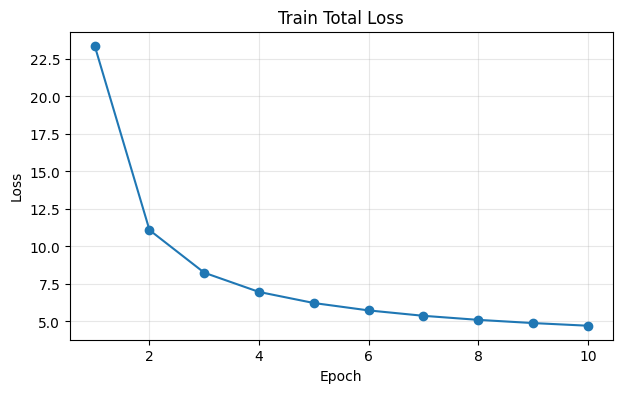

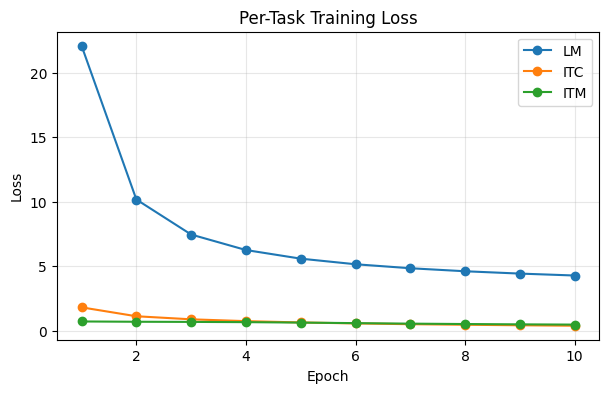

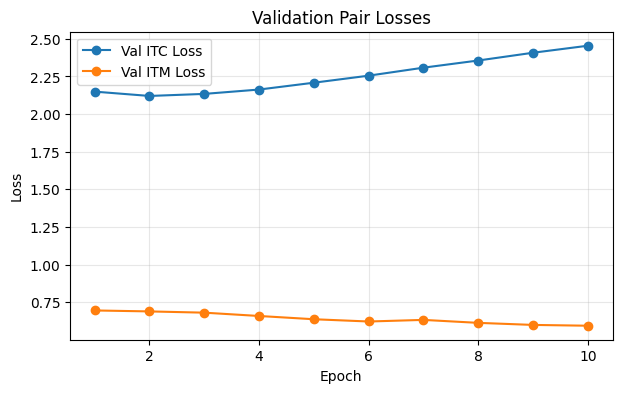

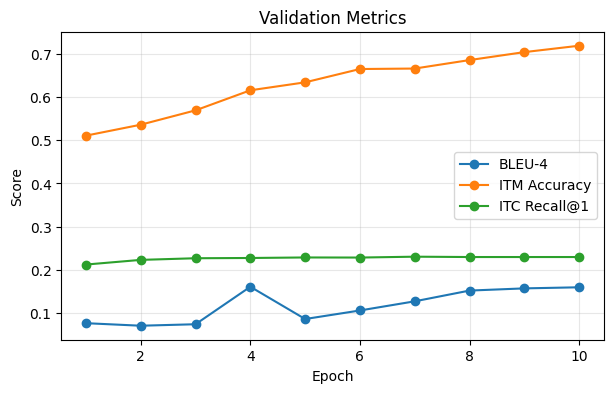

In [12]:

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_total_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Total Loss")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_lm_loss"], marker="o", label="LM")
plt.plot(history_df["epoch"], history_df["train_itc_loss"], marker="o", label="ITC")
plt.plot(history_df["epoch"], history_df["train_itm_loss"], marker="o", label="ITM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Per-Task Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["val_itc_loss"], marker="o", label="Val ITC Loss")
plt.plot(history_df["epoch"], history_df["val_itm_loss"], marker="o", label="Val ITM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Pair Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["BLEU-4"], marker="o", label="BLEU-4")
plt.plot(history_df["epoch"], history_df["val_itm_acc"], marker="o", label="ITM Accuracy")
plt.plot(history_df["epoch"], history_df["val_itc_r1"], marker="o", label="ITC Recall@1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Final validation check

In [13]:

if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval()

final_pair_metrics = evaluate_itc_itm(model, val_loader, DEVICE)
final_bleu = evaluate_lm_bleu(model, val_df, tokenizer, processor, DEVICE, max_images=cfg.max_bleu_eval_images)
final_report = {**final_pair_metrics, **final_bleu}
pd.DataFrame([final_report])


BLEU eval: 100%|██████████| 300/300 [01:02<00:00,  4.80it/s]


,val_itc_loss,val_itm_loss,val_itm_acc,val_itc_r1,BLEU-1,BLEU-2,BLEU-3,BLEU-4
0,2.163293,0.660988,0.608327,0.227835,0.531324,0.35754,0.238648,0.161393


LM works if captions are non-empty and BLEU is above near-zero baseline. ITM works if accuracy is clearly above 0.50. ITC works if Recall@1 is above random batch chance and trends upward.

## Qualitative examples

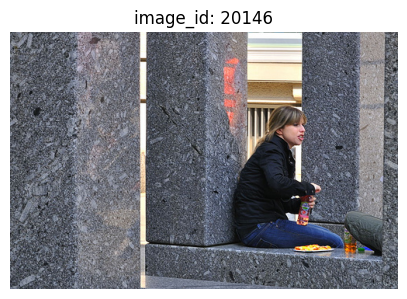

Predicted: A man in a blue shirt is sitting on a bench.....................
Ground truth captions:
  1. The blond girl is opening her drink as she speaks to the person with her.
  2. A girl opening her bottled drink while having lunch with a friend.
  3. A girl in a black jacket sitting on a ledge talking to someone.
  4. Two people sitting on a cement bench chatting over lunch.
  5. A woman is sitting in a marble ledge.
--------------------------------------------------------------------------------


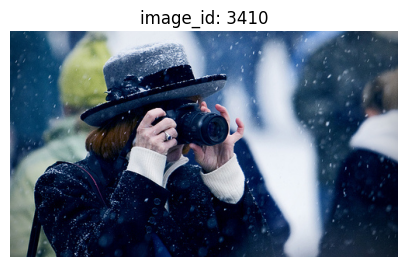

Predicted: A man in a black hat is holding a camera......................
Ground truth captions:
  1. A woman in a gray hat is aiming her camera in the snow as to take a picture.
  2. The lady wearing a black hat is taking a picture while the snowfalls.
  3. A person wearing a hat takes a picture while its snowing.
  4. A person wearing a blue hat takes a photo in the snow.
  5. A woman takes a picture as it snows.
--------------------------------------------------------------------------------


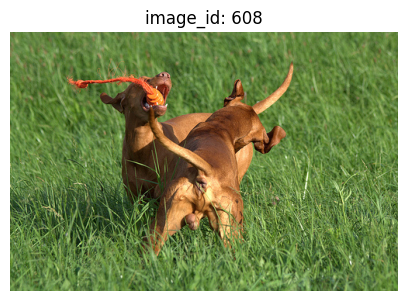

Predicted: A brown dog is running through the grass........................
Ground truth captions:
  1. Two dogs are playing rough in a green field of grass.
  2. On grass, two brown dogs tussle for orange toy.
  3. Two dogs play with an orange toy in tall grass.
  4. Two large brown dogs are playing in the grass.
  5. Dogs fight in grass over toy.
--------------------------------------------------------------------------------


In [14]:

val_unique = val_df.drop_duplicates("image_id").reset_index(drop=True)
sample_idx = random.sample(range(len(val_unique)), k=min(cfg.qualitative_examples, len(val_unique)))

for idx in sample_idx:
    row = val_unique.iloc[idx]
    image = row["image"]
    pred = generate_caption(model, processor, tokenizer, image, DEVICE, max_len=cfg.max_len)
    refs = val_df[val_df["image_id"] == row["image_id"]]["caption"].tolist()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"image_id: {row['image_id']}")
    plt.show()

    print("Predicted:", pred)
    print("Ground truth captions:")
    for i, cap in enumerate(refs[:5], 1):
        print(f"  {i}. {cap}")
    print("-" * 80)
